# Taller 3 – Transformer para análisis de sentimientos turísticos en español


Juan Manuel Hurtado Angulo

Manuel Alberto Gonzalez Gonzalez

William Alberto Reina García



**Dataset:** `alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad`  
**Objetivo del entregable:** construir una arquitectura tipo Transformer para clasificación de sentimientos (1 a 5 estrellas), comparando:

1. **Positional Encoding sinusoidal** vs **learnable positional embedding**.  
2. **Dos tokenizadores distintos** de Hugging Face.  
3. Una configuración de **embedding pequeño** y otra de **embedding grande**.  
4. Diferentes valores del parámetro **beta** en la atención escalada.  

Además, este notebook deja explícito:

- por qué `embed_dim` debe ser divisible por `num_heads`,
- que la salida de `MultiHeadAttention` conserva la forma `(batch, seq_len, embed_dim)`,
- cuál es la dimensión clave que llega al clasificador,
- cómo documentar y justificar los cambios frente al notebook base del profesor.

---

## Arquitectura propuesta

La arquitectura que se va a entregar esta semana puede describirse así:

**Texto → Tokenizador → Token Embedding → Positional Embedding → N bloques Transformer → Pooling en secuencia → Clasificador MLP → 5 clases**

La **dimensión importante para el output del encoder** es `embed_dim`, porque cada token sale representado como un vector de tamaño `embed_dim`.  
Después se hace **pooling** sobre la dimensión temporal (`seq_len`) para obtener un vector por ejemplo, de forma:

- salida del encoder: `(batch, seq_len, embed_dim)`
- salida tras pooling: `(batch, embed_dim)`
- salida del clasificador: `(batch, num_classes)`



In [1]:
# Si trabajas en Google Colab, descomenta esta celda la primera vez.
# !pip install -q datasets transformers evaluate scikit-learn tqdm

## 1. Importaciones y configuración general

En esta sección importamos librerías, fijamos semillas y definimos una configuración reproducible.

In [2]:
import os
import math
import random
from dataclasses import dataclass, asdict
from enum import Enum
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DEVICE)

Dispositivo: cuda


## 2. Carga del dataset

Usamos el mismo dataset del taller anterior
Suponemos las columnas:

- `text`: texto turístico en español
- `label`: polaridad de 1 a 5 estrellas

Si el dataset trae la etiqueta como 1–5, la convertimos a 0–4 para entrenar con `CrossEntropyLoss`.

In [3]:
raw_dataset = load_dataset("alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad")
raw_dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/495 [00:00<?, ?B/s]

data/train-00000-of-00001-40d9940488cb84(…):   0%|          | 0.00/43.7M [00:00<?, ?B/s]

data/test-00000-of-00001-9cc7bacfd2a73ac(…):   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/176192 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/75510 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 176192
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 75510
    })
})

In [4]:
# Unificamos una sola tabla y construimos split reproducible.
# Si el dataset ya trae splits, esta lógica sigue siendo útil para inspección.
if "train" in raw_dataset:
    base_ds = raw_dataset["train"]
else:
    # En caso raro de que venga con otro nombre de split.
    first_split = list(raw_dataset.keys())[0]
    base_ds = raw_dataset[first_split]

# Renombramos para hacer el notebook más claro.
df = pd.DataFrame(base_ds)
print(df.head())
print("\nColumnas:", list(df.columns))
print("\nDistribución de etiquetas:")
print(df["label"].value_counts().sort_index())

label_min = int(df["label"].min())
label_max = int(df["label"].max())
num_classes = label_max - label_min + 1

print(f"Rango original de labels: {label_min} a {label_max}")
print(f"Número de clases: {num_classes}")

                                                text  label
0  el mejor lugar para comer sushi. excelente lug...      5
1  vista hermosa!. me sorprendió la maravillosa v...      5
2  desastroso. buenas noches,  ante todo explicar...      1
3  todo bien excepto que se niegan a dar vasos de...      3
4  el mejor zoologico de méxico. el ambiente es m...      5

Columnas: ['text', 'label']

Distribución de etiquetas:
label
1      4050
2      4833
3     15261
4     42232
5    109816
Name: count, dtype: int64
Rango original de labels: 1 a 5
Número de clases: 5


## 3. División de datos

Creamos `train`, `validation` y `test` manteniendo reproducibilidad.

In [5]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (140953, 2)
Val  : (17619, 2)
Test : (17620, 2)


## 4. Comparación de tokenizadores


Aquí probamos dos opciones razonables para español:

1. `dccuchile/bert-base-spanish-wwm-cased`  
2. `bert-base-multilingual-cased`

La idea no es solo cambiar el tokenizador por cambiarlo, sino medir al menos:

- longitud media de secuencia,
- cobertura / presencia de tokens desconocidos,
- rendimiento final del modelo.

En muchos casos, un tokenizador que fragmenta menos el texto puede ser más eficiente.

In [6]:
TOKENIZER_CANDIDATES = {
    "beto": "dccuchile/bert-base-spanish-wwm-cased",
    "mbert": "bert-base-multilingual-cased",
}

sample_texts = train_df["text"].sample(min(300, len(train_df)), random_state=SEED).tolist()

def compare_tokenizers(tokenizer_names: Dict[str, str], texts: List[str], max_length: int = 128) -> pd.DataFrame:
    rows = []
    for short_name, hf_name in tokenizer_names.items():
        tokenizer = AutoTokenizer.from_pretrained(hf_name)
        unk_token_id = tokenizer.unk_token_id
        lengths = []
        unk_counts = 0
        total_tokens = 0

        for text in texts:
            encoded = tokenizer(
                text,
                truncation=True,
                max_length=max_length,
                padding=False
            )
            ids = encoded["input_ids"]
            lengths.append(len(ids))
            total_tokens += len(ids)
            if unk_token_id is not None:
                unk_counts += sum(1 for tid in ids if tid == unk_token_id)

        rows.append({
            "tokenizer_alias": short_name,
            "hf_name": hf_name,
            "avg_tokens": np.mean(lengths),
            "max_tokens_observed": np.max(lengths),
            "unk_ratio": unk_counts / max(total_tokens, 1),
        })

    return pd.DataFrame(rows).sort_values(["avg_tokens", "unk_ratio"], ascending=[True, True])

tokenizer_report = compare_tokenizers(TOKENIZER_CANDIDATES, sample_texts)
tokenizer_report

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,tokenizer_alias,hf_name,avg_tokens,max_tokens_observed,unk_ratio
0,beto,dccuchile/bert-base-spanish-wwm-cased,72.076667,128,0.000647
1,mbert,bert-base-multilingual-cased,80.240000,128,0.000125


### Criterio de selección del tokenizador

Una forma razonable de justificar la elección es:

- **primer criterio:** menor fragmentación (`avg_tokens`),
- **segundo criterio:** menor `unk_ratio`,
- **tercer criterio:** mejor desempeño en validación.


In [7]:
# Escoge aquí el tokenizador base para la primera ronda de pruebas.
SELECTED_TOKENIZER_ALIAS = tokenizer_report.iloc[0]["tokenizer_alias"]
SELECTED_TOKENIZER_NAME = TOKENIZER_CANDIDATES[SELECTED_TOKENIZER_ALIAS]

print("Tokenizador inicialmente seleccionado:", SELECTED_TOKENIZER_ALIAS)
print("Modelo HF:", SELECTED_TOKENIZER_NAME)

tokenizer = AutoTokenizer.from_pretrained(SELECTED_TOKENIZER_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.sep_token
print("Pad token:", tokenizer.pad_token, "| pad_token_id:", tokenizer.pad_token_id)

Tokenizador inicialmente seleccionado: beto
Modelo HF: dccuchile/bert-base-spanish-wwm-cased
Pad token: [PAD] | pad_token_id: 1


## 5. Longitud máxima de secuencia

No conviene fijar `max_len` arbitrariamente sin revisar los datos.  
Aquí calculamos una aproximación basada en percentiles para no desperdiciar memoria.

In [8]:
def token_lengths(texts: List[str], tokenizer, max_probe: Optional[int] = None) -> List[int]:
    lengths = []
    iterable = texts if max_probe is None else texts[:max_probe]
    for text in tqdm(iterable, desc="Midiendo longitudes"):
        lengths.append(len(tokenizer(text, truncation=False)["input_ids"]))
    return lengths

train_texts_for_probe = train_df["text"].tolist()[: min(2000, len(train_df))]
lengths = token_lengths(train_texts_for_probe, tokenizer)

length_stats = pd.Series(lengths).describe(percentiles=[0.80, 0.90, 0.95, 0.99])
length_stats

Midiendo longitudes:   0%|          | 0/2000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (540 > 512). Running this sequence through the model will result in indexing errors


,0
count,2000.000000
mean,83.627000
std,86.322834
min,17.000000
50%,62.000000
80%,104.000000
90%,159.000000
95%,188.000000
99%,407.000000
max,1529.000000


In [9]:
# El profesor pidió experimentar con embedding pequeño y grande.
# También definimos un max_len razonable según percentil.
MAX_LEN = int(np.percentile(lengths, 95))
MAX_LEN = min(MAX_LEN, 256)  # límite práctico para Colab / GPU modesta
print("MAX_LEN seleccionado:", MAX_LEN)

MAX_LEN seleccionado: 188


## 6. Dataset de PyTorch

Esta clase tokeniza cada texto y devuelve:

- `input_ids`
- `attention_mask`
- `labels`

Las etiquetas se normalizan a `0..num_classes-1`.

In [10]:
class TourismSentimentDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_len: int):
        self.df = dataframe.reset_index(drop=True).copy()
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Convertimos 1..5 -> 0..4 (si el mínimo es 1)
        self.df["label_zero_based"] = self.df["label"] - self.df["label"].min()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        encoded = self.tokenizer(
            row["text"],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0).long(),
            "attention_mask": encoded["attention_mask"].squeeze(0).long(),
            "labels": torch.tensor(int(row["label_zero_based"]), dtype=torch.long)
        }

In [11]:
train_dataset = TourismSentimentDataset(train_df, tokenizer, MAX_LEN)
val_dataset = TourismSentimentDataset(val_df, tokenizer, MAX_LEN)
test_dataset = TourismSentimentDataset(test_df, tokenizer, MAX_LEN)

BATCH_SIZE = 32 if DEVICE == "cuda" else 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_batch = next(iter(train_loader))
{k: tuple(v.shape) for k, v in sample_batch.items()}

{'input_ids': (32, 188), 'attention_mask': (32, 188), 'labels': (32,)}

## 7. Positional Encoding: sinusoidal y aprendible

Aquí están las dos variantes

### 7.1 Sinusoidal


### 7.2 Learnable positional embedding


In [12]:
class PosEncodingType(Enum):
    SINUSOIDAL = "sinusoidal"
    LEARNABLE = "learnable"


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()

        position = torch.arange(max_len).unsqueeze(1)                       # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )                                                                   # (d_model/2,)

        pe = torch.zeros(max_len, d_model, dtype=torch.float32)            # (max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)                       # índices pares
        pe[:, 1::2] = torch.cos(position * div_term)                       # índices impares

        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)      # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class LearnablePositionalEncoding(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        self.position_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        batch_size, seq_len, d_model = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        pos_emb = self.position_embedding(positions)                       # (batch, seq_len, d_model)
        return x + pos_emb


class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size: int, max_len: int, embed_dim: int, pos_encoding_type: PosEncodingType):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.embed_scale = math.sqrt(embed_dim)

        if pos_encoding_type == PosEncodingType.SINUSOIDAL:
            self.position_embedding = SinusoidalPositionalEncoding(max_len, embed_dim)
        else:
            self.position_embedding = LearnablePositionalEncoding(max_len, embed_dim)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        # input_ids: (batch, seq_len)
        x = self.token_embedding(input_ids) * self.embed_scale            # (batch, seq_len, embed_dim)
        x = self.position_embedding(x)                                    # (batch, seq_len, embed_dim)
        return x

In [13]:
# Prueba rápida de forma
vocab_size = tokenizer.vocab_size
embed_dim_demo = 128

emb_layer_sin = TokenAndPositionEmbedding(
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embed_dim=embed_dim_demo,
    pos_encoding_type=PosEncodingType.SINUSOIDAL
)

emb_layer_learn = TokenAndPositionEmbedding(
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embed_dim=embed_dim_demo,
    pos_encoding_type=PosEncodingType.LEARNABLE
)

x_demo = sample_batch["input_ids"][:2]
out_sin = emb_layer_sin(x_demo)
out_lrn = emb_layer_learn(x_demo)

print("Input ids shape           :", x_demo.shape)
print("Salida con sinusoidal     :", out_sin.shape)
print("Salida con learned        :", out_lrn.shape)

Input ids shape           : torch.Size([2, 188])
Salida con sinusoidal     : torch.Size([2, 188, 128])
Salida con learned        : torch.Size([2, 188, 128])


## 8. Multi-Head Self-Attention


In [14]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, beta: float = 1.0, dropout: float = 0.1):
        super().__init__()

        # Regla fundamental:
        # embed_dim debe ser divisible por num_heads.
        assert embed_dim % num_heads == 0, (
            f"embed_dim={embed_dim} no es divisible por num_heads={num_heads}"
        )

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.beta = beta

        # Todas las capas lineales preservan el tamaño embed_dim.
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, embed_dim)
        batch_size, seq_len, _ = x.shape
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)  # (batch, num_heads, seq_len, head_dim)
        return x

    def _combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, num_heads, seq_len, head_dim)
        batch_size, num_heads, seq_len, head_dim = x.shape
        x = x.transpose(1, 2).contiguous().view(batch_size, seq_len, num_heads * head_dim)
        return x  # (batch, seq_len, embed_dim)

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None, return_attention: bool = False):
        # x: (batch, seq_len, embed_dim)
        batch_size, seq_len, embed_dim = x.shape
        assert embed_dim == self.embed_dim, "La última dimensión debe coincidir con embed_dim"

        q = self.q_proj(x)  # (batch, seq_len, embed_dim)
        k = self.k_proj(x)  # (batch, seq_len, embed_dim)
        v = self.v_proj(x)  # (batch, seq_len, embed_dim)

        q = self._split_heads(q)  # (batch, heads, seq_len, head_dim)
        k = self._split_heads(k)  # (batch, heads, seq_len, head_dim)
        v = self._split_heads(v)  # (batch, heads, seq_len, head_dim)

        # Atención escalada
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = self.beta * scores  # parámetro experimental pedido por el profesor

        if attention_mask is not None:
            # attention_mask: (batch, seq_len)
            mask = attention_mask.unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq_len)
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attention_weights = torch.softmax(scores, dim=-1)   # (batch, heads, seq_len, seq_len)
        attention_weights = self.attn_dropout(attention_weights)

        context = torch.matmul(attention_weights, v)        # (batch, heads, seq_len, head_dim)
        context = self._combine_heads(context)              # (batch, seq_len, embed_dim)
        output = self.out_proj(context)                     # (batch, seq_len, embed_dim)

        # La atención debe devolver la misma forma que entró.
        assert output.shape == (batch_size, seq_len, self.embed_dim), (
            f"Se esperaba {(batch_size, seq_len, self.embed_dim)} y se obtuvo {tuple(output.shape)}"
        )

        if return_attention:
            return output, attention_weights
        return output

In [15]:
# Verificación de shapes
attn = MultiHeadSelfAttention(embed_dim=128, num_heads=8, beta=1.0)
x = out_sin[:2]  # (batch, seq_len, embed_dim)
mask = sample_batch["attention_mask"][:2]

attn_out, attn_weights = attn(x, attention_mask=mask, return_attention=True)

print("x                    :", x.shape)
print("attention output     :", attn_out.shape)
print("attention weights    :", attn_weights.shape)
print("\nImportante:")
print("- La salida conserva (batch, seq_len, embed_dim).")
print("- La matriz de atención tiene forma (batch, heads, seq_len, seq_len).")

x                    : torch.Size([2, 188, 128])
attention output     : torch.Size([2, 188, 128])
attention weights    : torch.Size([2, 8, 188, 188])

Importante:
- La salida conserva (batch, seq_len, embed_dim).
- La matriz de atención tiene forma (batch, heads, seq_len, seq_len).


## 9. Bloque Transformer

El bloque estándar tiene:

1. Multi-Head Self-Attention  
2. Residual + LayerNorm  
3. Feed Forward Network  
4. Residual + LayerNorm

También dejamos hiperparámetros

- `dropout`
- `ff_multiplier`
- `beta`

In [16]:
class TransformerEncoderBlock(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        ff_multiplier: int = 4,
        dropout: float = 0.1,
        beta: float = 1.0
    ):
        super().__init__()

        self.attention = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            beta=beta,
            dropout=dropout
        )

        ff_dim = ff_multiplier * embed_dim

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim)
        )

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        # Bloque de atención + residual
        attn_out = self.attention(x, attention_mask=attention_mask)
        x = self.norm1(x + self.dropout1(attn_out))

        # Bloque feed-forward + residual
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))

        return x

## 10. Encoder Transformer completo

Apilamos varios bloques.  
La **salida** mantiene forma `(batch, seq_len, embed_dim)`.

In [17]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        num_layers: int,
        embed_dim: int,
        num_heads: int,
        ff_multiplier: int = 4,
        dropout: float = 0.1,
        beta: float = 1.0
    ):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_multiplier=ff_multiplier,
                dropout=dropout,
                beta=beta
            )
            for _ in range(num_layers)
        ])

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x, attention_mask=attention_mask)
        return x

## 11. Clasificador final

En vez de aplanar toda la secuencia (`Flatten`) como en el notebook base, aquí usamos **masked mean pooling**.  


`(batch, embed_dim)`



In [18]:
def masked_mean_pooling(x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    # x: (batch, seq_len, embed_dim)
    # attention_mask: (batch, seq_len)
    mask = attention_mask.unsqueeze(-1).float()             # (batch, seq_len, 1)
    x_masked = x * mask
    summed = x_masked.sum(dim=1)                            # (batch, embed_dim)
    counts = mask.sum(dim=1).clamp(min=1e-9)                # (batch, 1)
    return summed / counts


class SentimentTransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_len: int,
        num_classes: int,
        embed_dim: int,
        num_heads: int,
        num_layers: int,
        pos_encoding_type: PosEncodingType,
        ff_multiplier: int = 4,
        dropout: float = 0.1,
        beta: float = 1.0
    ):
        super().__init__()

        self.embedding = TokenAndPositionEmbedding(
            vocab_size=vocab_size,
            max_len=max_len,
            embed_dim=embed_dim,
            pos_encoding_type=pos_encoding_type
        )

        self.encoder = TransformerEncoder(
            num_layers=num_layers,
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_multiplier=ff_multiplier,
            dropout=dropout,
            beta=beta
        )

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_ids)                        # (batch, seq_len, embed_dim)
        x = self.encoder(x, attention_mask=attention_mask)  # (batch, seq_len, embed_dim)
        x = masked_mean_pooling(x, attention_mask)          # (batch, embed_dim)
        logits = self.classifier(x)                         # (batch, num_classes)
        return logits

In [19]:
# Prueba rápida del clasificador
model_demo = SentimentTransformerClassifier(
    vocab_size=tokenizer.vocab_size,
    max_len=MAX_LEN,
    num_classes=num_classes,
    embed_dim=128,
    num_heads=8,
    num_layers=2,
    pos_encoding_type=PosEncodingType.SINUSOIDAL,
    dropout=0.1,
    beta=1.0
)

demo_logits = model_demo(sample_batch["input_ids"], sample_batch["attention_mask"])
print("Logits shape:", demo_logits.shape)
print("Debe ser (batch, num_classes).")

Logits shape: torch.Size([32, 5])
Debe ser (batch, num_classes).


## 12. Configuración de experimentos

Definimos una estructura centralizada para poder experimentar con:

- tokenizador,
- positional encoding,
- embedding pequeño o grande,
- número de cabezas,
- dropout,
- número de capas,
- `beta`.

### Regla importante
`embed_dim % num_heads == 0`

Ejemplos válidos:

- `embed_dim=128`, `num_heads=8`
- `embed_dim=256`, `num_heads=8`
- `embed_dim=256`, `num_heads=4`

Ejemplos inválidos:

- `embed_dim=130`, `num_heads=8`

In [20]:
@dataclass
class ExperimentConfig:
    tokenizer_name: str
    tokenizer_alias: str
    pos_encoding_type: PosEncodingType
    max_len: int = MAX_LEN
    embed_dim: int = 128
    num_heads: int = 8
    num_layers: int = 2
    ff_multiplier: int = 4
    dropout: float = 0.1
    beta: float = 1.0
    lr: float = 2e-4
    weight_decay: float = 1e-4
    epochs: int = 4

    def __post_init__(self):
        assert self.embed_dim % self.num_heads == 0, (
            "embed_dim debe ser divisible por num_heads"
        )


SMALL_EMBED_CONFIG = {
    "embed_dim": 128,
    "num_heads": 8
}

LARGE_EMBED_CONFIG = {
    "embed_dim": 256,
    "num_heads": 8
}

## 13. Funciones de entrenamiento y evaluación

Estas funciones permiten correr experimentos comparables y guardar métricas.

In [21]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Entrenando", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    metrics = {
        "loss": total_loss / max(len(loader), 1),
        "acc": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro")
    }
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, split_name="Val"):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc=f"Evaluando {split_name}", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    metrics = {
        "loss": total_loss / max(len(loader), 1),
        "acc": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
        "y_true": all_labels,
        "y_pred": all_preds
    }
    return metrics

## 14. Función para correr un experimento completo

Esta función:

1. crea el tokenizador,
2. construye los datasets,
3. instancia el modelo,
4. entrena,
5. evalúa en validación y prueba,
6. devuelve un resumen listo para comparar.

In [22]:
def build_loaders_for_tokenizer(tokenizer_name: str, max_len: int, batch_size: int):
    tokenizer_local = AutoTokenizer.from_pretrained(tokenizer_name)
    if tokenizer_local.pad_token is None:
        tokenizer_local.pad_token = tokenizer_local.eos_token if tokenizer_local.eos_token is not None else tokenizer_local.sep_token

    train_ds = TourismSentimentDataset(train_df, tokenizer_local, max_len)
    val_ds = TourismSentimentDataset(val_df, tokenizer_local, max_len)
    test_ds = TourismSentimentDataset(test_df, tokenizer_local, max_len)

    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_ld = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_ld = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return tokenizer_local, train_ld, val_ld, test_ld


def run_experiment(config: ExperimentConfig, batch_size: Optional[int] = None):
    set_seed(SEED)

    if batch_size is None:
        batch_size = 32 if DEVICE == "cuda" else 8

    tokenizer_local, train_ld, val_ld, test_ld = build_loaders_for_tokenizer(
        config.tokenizer_name,
        config.max_len,
        batch_size
    )

    model = SentimentTransformerClassifier(
        vocab_size=tokenizer_local.vocab_size,
        max_len=config.max_len,
        num_classes=num_classes,
        embed_dim=config.embed_dim,
        num_heads=config.num_heads,
        num_layers=config.num_layers,
        pos_encoding_type=config.pos_encoding_type,
        ff_multiplier=config.ff_multiplier,
        dropout=config.dropout,
        beta=config.beta
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    total_steps = len(train_ld) * config.epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.1 * total_steps)),
        num_training_steps=max(1, total_steps)
    )

    history = []

    best_val_f1 = -1
    best_state = None

    for epoch in range(1, config.epochs + 1):
        train_metrics = train_one_epoch(model, train_ld, optimizer, scheduler, criterion, DEVICE)
        val_metrics = evaluate(model, val_ld, criterion, DEVICE, split_name="Val")

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_macro_f1": val_metrics["macro_f1"],
        }
        history.append(row)
        print(row)

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate(model, test_ld, criterion, DEVICE, split_name="Test")

    summary = {
        **asdict(config),
        "pos_encoding_type": config.pos_encoding_type.value,
        "best_val_macro_f1": best_val_f1,
        "test_acc": test_metrics["acc"],
        "test_macro_f1": test_metrics["macro_f1"],
        "history": pd.DataFrame(history),
        "classification_report": classification_report(
            test_metrics["y_true"],
            test_metrics["y_pred"],
            digits=4
        )
    }

    return summary, model, tokenizer_local

## 15. Experimentos mínimos exigidos



1. Tokenizador A + Sinusoidal  
2. Tokenizador A + Learnable  
3. Tokenizador B + Sinusoidal  
4. Tokenizador B + Learnable  

Y adicionalmente, si hay tiempo/GPU:

5. embedding pequeño  
6. embedding grande  
7. beta = 0.8, 1.0, 1.2

In [23]:
base_experiments = [
    ExperimentConfig(
        tokenizer_name=TOKENIZER_CANDIDATES["beto"],
        tokenizer_alias="beto",
        pos_encoding_type=PosEncodingType.SINUSOIDAL,
        **SMALL_EMBED_CONFIG
    ),
    ExperimentConfig(
        tokenizer_name=TOKENIZER_CANDIDATES["beto"],
        tokenizer_alias="beto",
        pos_encoding_type=PosEncodingType.LEARNABLE,
        **SMALL_EMBED_CONFIG
    ),
    ExperimentConfig(
        tokenizer_name=TOKENIZER_CANDIDATES["mbert"],
        tokenizer_alias="mbert",
        pos_encoding_type=PosEncodingType.SINUSOIDAL,
        **SMALL_EMBED_CONFIG
    ),
    ExperimentConfig(
        tokenizer_name=TOKENIZER_CANDIDATES["mbert"],
        tokenizer_alias="mbert",
        pos_encoding_type=PosEncodingType.LEARNABLE,
        **SMALL_EMBED_CONFIG
    ),
]

base_experiments

[ExperimentConfig(tokenizer_name='dccuchile/bert-base-spanish-wwm-cased', tokenizer_alias='beto', pos_encoding_type=<PosEncodingType.SINUSOIDAL: 'sinusoidal'>, max_len=188, embed_dim=128, num_heads=8, num_layers=2, ff_multiplier=4, dropout=0.1, beta=1.0, lr=0.0002, weight_decay=0.0001, epochs=4),
 ExperimentConfig(tokenizer_name='dccuchile/bert-base-spanish-wwm-cased', tokenizer_alias='beto', pos_encoding_type=<PosEncodingType.LEARNABLE: 'learnable'>, max_len=188, embed_dim=128, num_heads=8, num_layers=2, ff_multiplier=4, dropout=0.1, beta=1.0, lr=0.0002, weight_decay=0.0001, epochs=4),
 ExperimentConfig(tokenizer_name='bert-base-multilingual-cased', tokenizer_alias='mbert', pos_encoding_type=<PosEncodingType.SINUSOIDAL: 'sinusoidal'>, max_len=188, embed_dim=128, num_heads=8, num_layers=2, ff_multiplier=4, dropout=0.1, beta=1.0, lr=0.0002, weight_decay=0.0001, epochs=4),
 ExperimentConfig(tokenizer_name='bert-base-multilingual-cased', tokenizer_alias='mbert', pos_encoding_type=<PosEnco

## 16. Ejecución de experimentos


La siguiente celda está lista para correr todos los experimentos y consolidar resultados.

## 16. Ejecución de experimentos



1. corre experimentos,
2. guarda métricas e historiales,
3. conserva los modelos entrenados en memoria,
4. selecciona automáticamente el mejor,
5. evalúa en test,
6. genera predicciones sobre ejemplos manuales y ejemplos reales.



In [24]:
# =========================
# PLAN DE EJECUCIÓN
# =========================
# Puedes cambiar estos valores si quieres acelerar pruebas rápidas.
# Para la entrega se recomienda dejar:
# EXECUTION_MODE = "deliverable"

EXECUTION_MODE = "deliverable"   # opciones: "smoke_test", "balanced", "deliverable"
RUN_OPTIONAL_TUNING = True       # incluye experimentos extra con beta / embedding grande
SAVE_BEST_WEIGHTS = True

if EXECUTION_MODE == "smoke_test":
    DEFAULT_EPOCHS = 1
    DEFAULT_BATCH_SIZE = 8 if DEVICE == "cpu" else 16
    TRAIN_SAMPLE_FRAC = 0.20
    VAL_SAMPLE_FRAC = 0.30
    TEST_SAMPLE_FRAC = 0.30
elif EXECUTION_MODE == "balanced":
    DEFAULT_EPOCHS = 2 if DEVICE == "cpu" else 3
    DEFAULT_BATCH_SIZE = 8 if DEVICE == "cpu" else 24
    TRAIN_SAMPLE_FRAC = 0.60 if DEVICE == "cpu" else 1.0
    VAL_SAMPLE_FRAC = 1.0
    TEST_SAMPLE_FRAC = 1.0
else:  # deliverable
    DEFAULT_EPOCHS = 3 if DEVICE == "cpu" else 4
    DEFAULT_BATCH_SIZE = 8 if DEVICE == "cpu" else 32
    TRAIN_SAMPLE_FRAC = 1.0
    VAL_SAMPLE_FRAC = 1.0
    TEST_SAMPLE_FRAC = 1.0

print({
    "DEVICE": DEVICE,
    "EXECUTION_MODE": EXECUTION_MODE,
    "DEFAULT_EPOCHS": DEFAULT_EPOCHS,
    "DEFAULT_BATCH_SIZE": DEFAULT_BATCH_SIZE,
    "TRAIN_SAMPLE_FRAC": TRAIN_SAMPLE_FRAC,
    "VAL_SAMPLE_FRAC": VAL_SAMPLE_FRAC,
    "TEST_SAMPLE_FRAC": TEST_SAMPLE_FRAC,
    "RUN_OPTIONAL_TUNING": RUN_OPTIONAL_TUNING,
})


{'DEVICE': 'cuda', 'EXECUTION_MODE': 'deliverable', 'DEFAULT_EPOCHS': 4, 'DEFAULT_BATCH_SIZE': 32, 'TRAIN_SAMPLE_FRAC': 1.0, 'VAL_SAMPLE_FRAC': 1.0, 'TEST_SAMPLE_FRAC': 1.0, 'RUN_OPTIONAL_TUNING': True}


In [25]:
def maybe_sample_dataframe(df_in: pd.DataFrame, frac: float, seed: int = SEED) -> pd.DataFrame:
    if frac >= 0.999:
        return df_in.reset_index(drop=True).copy()
    sampled = df_in.groupby("label", group_keys=False).apply(
        lambda x: x.sample(max(1, int(len(x) * frac)), random_state=seed)
    )
    return sampled.sample(frac=1.0, random_state=seed).reset_index(drop=True)

train_df_run = maybe_sample_dataframe(train_df, TRAIN_SAMPLE_FRAC)
val_df_run = maybe_sample_dataframe(val_df, VAL_SAMPLE_FRAC)
test_df_run = maybe_sample_dataframe(test_df, TEST_SAMPLE_FRAC)

print("Tamaños para esta ejecución:")
print({
    "train_original": len(train_df),
    "train_run": len(train_df_run),
    "val_original": len(val_df),
    "val_run": len(val_df_run),
    "test_original": len(test_df),
    "test_run": len(test_df_run),
})


Tamaños para esta ejecución:
{'train_original': 140953, 'train_run': 140953, 'val_original': 17619, 'val_run': 17619, 'test_original': 17620, 'test_run': 17620}


In [26]:
def build_loaders_for_tokenizer_runtime(tokenizer_name: str, max_len: int, batch_size: int):
    tokenizer_local = AutoTokenizer.from_pretrained(tokenizer_name)
    if tokenizer_local.pad_token is None:
        tokenizer_local.pad_token = (
            tokenizer_local.eos_token
            if tokenizer_local.eos_token is not None
            else tokenizer_local.sep_token
        )

    train_ds = TourismSentimentDataset(train_df_run, tokenizer_local, max_len)
    val_ds = TourismSentimentDataset(val_df_run, tokenizer_local, max_len)
    test_ds = TourismSentimentDataset(test_df_run, tokenizer_local, max_len)

    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_ld = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_ld = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return tokenizer_local, train_ld, val_ld, test_ld


In [27]:
def run_experiment_robust(config: ExperimentConfig, batch_size: Optional[int] = None, verbose: bool = True):
    set_seed(SEED)

    cfg = copy.deepcopy(config)
    cfg.epochs = DEFAULT_EPOCHS if cfg.epochs is None or cfg.epochs <= 0 else cfg.epochs

    if batch_size is None:
        batch_size = DEFAULT_BATCH_SIZE

    tokenizer_local, train_ld, val_ld, test_ld = build_loaders_for_tokenizer_runtime(
        cfg.tokenizer_name,
        cfg.max_len,
        batch_size
    )

    model = SentimentTransformerClassifier(
        vocab_size=tokenizer_local.vocab_size,
        max_len=cfg.max_len,
        num_classes=num_classes,
        embed_dim=cfg.embed_dim,
        num_heads=cfg.num_heads,
        num_layers=cfg.num_layers,
        pos_encoding_type=cfg.pos_encoding_type,
        ff_multiplier=cfg.ff_multiplier,
        dropout=cfg.dropout,
        beta=cfg.beta
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    total_steps = max(1, len(train_ld) * cfg.epochs)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.1 * total_steps)),
        num_training_steps=total_steps
    )

    history = []
    best_val_f1 = -1.0
    best_state = None
    best_epoch = None

    for epoch in range(1, cfg.epochs + 1):
        train_metrics = train_one_epoch(model, train_ld, optimizer, scheduler, criterion, DEVICE)
        val_metrics = evaluate(model, val_ld, criterion, DEVICE, split_name="Val")

        row = {
            "epoch": epoch,
            "train_loss": float(train_metrics["loss"]),
            "train_acc": float(train_metrics["acc"]),
            "train_macro_f1": float(train_metrics["macro_f1"]),
            "val_loss": float(val_metrics["loss"]),
            "val_acc": float(val_metrics["acc"]),
            "val_macro_f1": float(val_metrics["macro_f1"]),
        }
        history.append(row)

        if verbose:
            print(row)

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = float(val_metrics["macro_f1"])
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate(model, test_ld, criterion, DEVICE, split_name="Test")

    run_name = (
        f"{cfg.tokenizer_alias}_"
        f"{cfg.pos_encoding_type.value}_"
        f"emb{cfg.embed_dim}_"
        f"h{cfg.num_heads}_"
        f"beta{cfg.beta}"
    )

    summary = {
        "run_name": run_name,
        **asdict(cfg),
        "pos_encoding_type": cfg.pos_encoding_type.value,
        "best_epoch": best_epoch,
        "best_val_loss": float(min([r["val_loss"] for r in history])),
        "best_val_accuracy": float(max([r["val_acc"] for r in history])),
        "best_val_macro_f1": float(best_val_f1),
        "test_loss": float(test_metrics["loss"]),
        "test_accuracy": float(test_metrics["acc"]),
        "test_macro_f1": float(test_metrics["macro_f1"]),
        "history": pd.DataFrame(history),
        "classification_report": classification_report(
            test_metrics["y_true"],
            test_metrics["y_pred"],
            digits=4
        ),
        "y_true_test": test_metrics["y_true"],
        "y_pred_test": test_metrics["y_pred"],
    }

    artifact = {
        "model": model,
        "tokenizer": tokenizer_local,
        "config": cfg,
        "history_df": pd.DataFrame(history)
    }

    if SAVE_BEST_WEIGHTS:
        os.makedirs("checkpoints_transformer_taller", exist_ok=True)
        ckpt_path = os.path.join("checkpoints_transformer_taller", f"{run_name}.pt")
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": asdict(cfg),
            "run_name": run_name
        }, ckpt_path)
        summary["checkpoint_path"] = ckpt_path
        artifact["checkpoint_path"] = ckpt_path

    return summary, artifact


## 17. Matriz de experimentos obligatorios

Estos son los experimentos mínimos

- **dos tokenizadores**,
- **sinusoidal vs learnable positional encoding**,
- misma tarea y mismo dataset,
- comparación objetiva con métricas.


In [28]:
required_experiments = [
    ExperimentConfig(
        tokenizer_name=TOKENIZER_CANDIDATES["beto"],
        tokenizer_alias="beto",
        pos_encoding_type=PosEncodingType.SINUSOIDAL,
        epochs=DEFAULT_EPOCHS,
        **SMALL_EMBED_CONFIG
    ),
    ExperimentConfig(
        tokenizer_name=TOKENIZER_CANDIDATES["beto"],
        tokenizer_alias="beto",
        pos_encoding_type=PosEncodingType.LEARNABLE,
        epochs=DEFAULT_EPOCHS,
        **SMALL_EMBED_CONFIG
    ),
    ExperimentConfig(
        tokenizer_name=TOKENIZER_CANDIDATES["mbert"],
        tokenizer_alias="mbert",
        pos_encoding_type=PosEncodingType.SINUSOIDAL,
        epochs=DEFAULT_EPOCHS,
        **SMALL_EMBED_CONFIG
    ),
    ExperimentConfig(
        tokenizer_name=TOKENIZER_CANDIDATES["mbert"],
        tokenizer_alias="mbert",
        pos_encoding_type=PosEncodingType.LEARNABLE,
        epochs=DEFAULT_EPOCHS,
        **SMALL_EMBED_CONFIG
    ),
]
pd.DataFrame([{
    "tokenizer_alias": e.tokenizer_alias,
    "tokenizer_name": e.tokenizer_name,
    "pos_encoding_type": e.pos_encoding_type.value,
    "embed_dim": e.embed_dim,
    "num_heads": e.num_heads,
    "epochs": e.epochs,
} for e in required_experiments])


,tokenizer_alias,tokenizer_name,pos_encoding_type,embed_dim,num_heads,epochs
0,beto,dccuchile/bert-base-spanish-wwm-cased,sinusoidal,128,8,4
1,beto,dccuchile/bert-base-spanish-wwm-cased,learnable,128,8,4
2,mbert,bert-base-multilingual-cased,sinusoidal,128,8,4
3,mbert,bert-base-multilingual-cased,learnable,128,8,4


## 18. Ejecución automática de los experimentos obligatorios


In [29]:
import copy

all_results = []
trained_artifacts = {}

for cfg in required_experiments:
    print("\n" + "=" * 110)
    print("Ejecutando experimento obligatorio:")
    print(cfg)
    summary, artifact = run_experiment_robust(cfg)
    all_results.append(summary)
    trained_artifacts[summary["run_name"]] = artifact

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["history", "classification_report", "y_true_test", "y_pred_test"]}
    for r in all_results
]).sort_values(
    ["best_val_macro_f1", "test_macro_f1", "best_val_accuracy", "test_accuracy"],
    ascending=False
).reset_index(drop=True)

results_df



Ejecutando experimento obligatorio:
ExperimentConfig(tokenizer_name='dccuchile/bert-base-spanish-wwm-cased', tokenizer_alias='beto', pos_encoding_type=<PosEncodingType.SINUSOIDAL: 'sinusoidal'>, max_len=188, embed_dim=128, num_heads=8, num_layers=2, ff_multiplier=4, dropout=0.1, beta=1.0, lr=0.0002, weight_decay=0.0001, epochs=4)


Entrenando:   0%|          | 0/4405 [00:00<?, ?it/s]

Evaluando Val:   0%|          | 0/551 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.8689187410199818, 'train_acc': 0.6513873418799174, 'train_macro_f1': 0.3395462410402795, 'val_loss': 0.7487549202520055, 'val_acc': 0.6761450706623532, 'val_macro_f1': 0.41433017252763554}


Entrenando:   0%|          | 0/4405 [00:00<?, ?it/s]

...

Entrenando:   0%|          | 0/4405 [00:00<?, ?it/s]

Evaluando Val:   0%|          | 0/551 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 0.6604331779222888, 'train_acc': 0.7176718480628295, 'train_macro_f1': 0.5267739205204715, 'val_loss': 0.7184410648532009, 'val_acc': 0.695442420114649, 'val_macro_f1': 0.4848451312533788}


Evaluando Test:   0%|          | 0/551 [00:00<?, ?it/s]

,run_name,tokenizer_name,tokenizer_alias,pos_encoding_type,max_len,embed_dim,num_heads,num_layers,ff_multiplier,dropout,...,weight_decay,epochs,best_epoch,best_val_loss,best_val_accuracy,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,checkpoint_path
0,mbert_sinusoidal_emb128_h8_beta1.0,bert-base-multilingual-cased,mbert,sinusoidal,188,128,8,2,4,0.1,...,0.0001,4,4,0.712188,0.697656,0.494840,0.714941,0.695516,0.485647,checkpoints_transformer_taller/mbert_sinusoida...
1,beto_learnable_emb128_h8_beta1.0,dccuchile/bert-base-spanish-wwm-cased,beto,learnable,188,128,8,2,4,0.1,...,0.0001,4,4,0.712154,0.697315,0.490048,0.710316,0.697276,0.497993,checkpoints_transformer_taller/beto_learnable_...
2,beto_sinusoidal_emb128_h8_beta1.0,dccuchile/bert-base-spanish-wwm-cased,beto,sinusoidal,188,128,8,2,4,0.1,...,0.0001,4,4,0.710591,0.697713,0.489339,0.713468,0.696141,0.493538,checkpoints_transformer_taller/beto_sinusoidal...
3,mbert_learnable_emb128_h8_beta1.0,bert-base-multilingual-cased,mbert,learnable,188,128,8,2,4,0.1,...,0.0001,4,4,0.715225,0.695442,0.484845,0.712529,0.695914,0.492031,checkpoints_transformer_taller/mbert_learnable...


## 19. Experimentos opcionales de ajuste fino

Después de comparar tokenizador y positional encoding, hacemos una segunda fase con:

- **embedding grande**,
- **beta distinto**,
- misma arquitectura base.

Esto permite mostrar que también se exploraron hiperparámetros

In [30]:
best_required_row = results_df.iloc[0]
best_required_tokenizer_alias = best_required_row["tokenizer_alias"]
best_required_pos_encoding = best_required_row["pos_encoding_type"]

best_required_tokenizer_name = TOKENIZER_CANDIDATES[best_required_tokenizer_alias]
best_required_pos_enum = PosEncodingType(best_required_pos_encoding)

optional_experiments = [
    ExperimentConfig(
        tokenizer_name=best_required_tokenizer_name,
        tokenizer_alias=best_required_tokenizer_alias,
        pos_encoding_type=best_required_pos_enum,
        embed_dim=256,
        num_heads=8,
        beta=0.8,
        epochs=DEFAULT_EPOCHS,
    ),
    ExperimentConfig(
        tokenizer_name=best_required_tokenizer_name,
        tokenizer_alias=best_required_tokenizer_alias,
        pos_encoding_type=best_required_pos_enum,
        embed_dim=256,
        num_heads=8,
        beta=1.0,
        epochs=DEFAULT_EPOCHS,
    ),
    ExperimentConfig(
        tokenizer_name=best_required_tokenizer_name,
        tokenizer_alias=best_required_tokenizer_alias,
        pos_encoding_type=best_required_pos_enum,
        embed_dim=256,
        num_heads=8,
        beta=1.2,
        epochs=DEFAULT_EPOCHS,
    ),
]

pd.DataFrame([{
    "tokenizer_alias": e.tokenizer_alias,
    "tokenizer_name": e.tokenizer_name,
    "pos_encoding_type": e.pos_encoding_type.value,
    "embed_dim": e.embed_dim,
    "num_heads": e.num_heads,
    "beta": e.beta,
    "epochs": e.epochs,
} for e in optional_experiments])


,tokenizer_alias,tokenizer_name,pos_encoding_type,embed_dim,num_heads,beta,epochs
0,mbert,bert-base-multilingual-cased,sinusoidal,256,8,0.8,4
1,mbert,bert-base-multilingual-cased,sinusoidal,256,8,1.0,4
2,mbert,bert-base-multilingual-cased,sinusoidal,256,8,1.2,4


In [31]:
if RUN_OPTIONAL_TUNING:
    for cfg in optional_experiments:
        print("\n" + "=" * 110)
        print("Ejecutando experimento opcional:")
        print(cfg)
        summary, artifact = run_experiment_robust(cfg)
        all_results.append(summary)
        trained_artifacts[summary["run_name"]] = artifact

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["history", "classification_report", "y_true_test", "y_pred_test"]}
    for r in all_results
]).sort_values(
    ["best_val_macro_f1", "test_macro_f1", "best_val_accuracy", "test_accuracy"],
    ascending=False
).reset_index(drop=True)

results_df



Ejecutando experimento opcional:
ExperimentConfig(tokenizer_name='bert-base-multilingual-cased', tokenizer_alias='mbert', pos_encoding_type=<PosEncodingType.SINUSOIDAL: 'sinusoidal'>, max_len=188, embed_dim=256, num_heads=8, num_layers=2, ff_multiplier=4, dropout=0.1, beta=0.8, lr=0.0002, weight_decay=0.0001, epochs=4)


Entrenando:   0%|          | 0/4405 [00:00<?, ?it/s]

Evaluando Val:   0%|          | 0/551 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.8272461545318535, 'train_acc': 0.6603832483168148, 'train_macro_f1': 0.37129952927623017, 'val_loss': 0.7489110489397862, 'val_acc': 0.6817072478574266, 'val_macro_f1': 0.406676864341308}


Entrenando:   0%|          | 0/4405 [00:00<?, ?it/s]

...

Entrenando:   0%|          | 0/4405 [00:00<?, ?it/s]

Evaluando Val:   0%|          | 0/551 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 0.646121479792438, 'train_acc': 0.721971153505069, 'train_macro_f1': 0.5442504494234923, 'val_loss': 0.6982390950357849, 'val_acc': 0.7031046029854134, 'val_macro_f1': 0.5063133504676445}


Evaluando Test:   0%|          | 0/551 [00:00<?, ?it/s]

,run_name,tokenizer_name,tokenizer_alias,pos_encoding_type,max_len,embed_dim,num_heads,num_layers,ff_multiplier,dropout,...,weight_decay,epochs,best_epoch,best_val_loss,best_val_accuracy,best_val_macro_f1,test_loss,test_accuracy,test_macro_f1,checkpoint_path
0,mbert_sinusoidal_emb256_h8_beta0.8,bert-base-multilingual-cased,mbert,sinusoidal,188,256,8,2,4,0.1,...,0.0001,4,4,0.703258,0.700551,0.511785,0.694132,0.704767,0.519562,checkpoints_transformer_taller/mbert_sinusoida...
1,mbert_sinusoidal_emb256_h8_beta1.2,bert-base-multilingual-cased,mbert,sinusoidal,188,256,8,2,4,0.1,...,0.0001,4,4,0.698239,0.703105,0.506313,0.693616,0.705562,0.516654,checkpoints_transformer_taller/mbert_sinusoida...
2,mbert_sinusoidal_emb256_h8_beta1.0,bert-base-multilingual-cased,mbert,sinusoidal,188,256,8,2,4,0.1,...,0.0001,4,4,0.698257,0.701686,0.501938,0.696162,0.706243,0.518649,checkpoints_transformer_taller/mbert_sinusoida...
3,mbert_sinusoidal_emb128_h8_beta1.0,bert-base-multilingual-cased,mbert,sinusoidal,188,128,8,2,4,0.1,...,0.0001,4,4,0.712188,0.697656,0.494840,0.714941,0.695516,0.485647,checkpoints_transformer_taller/mbert_sinusoida...
4,beto_learnable_emb128_h8_beta1.0,dccuchile/bert-base-spanish-wwm-cased,beto,learnable,188,128,8,2,4,0.1,...,0.0001,4,4,0.712154,0.697315,0.490048,0.710316,0.697276,0.497993,checkpoints_transformer_taller/beto_learnable_...
5,beto_sinusoidal_emb128_h8_beta1.0,dccuchile/bert-base-spanish-wwm-cased,beto,sinusoidal,188,128,8,2,4,0.1,...,0.0001,4,4,0.710591,0.697713,0.489339,0.713468,0.696141,0.493538,checkpoints_transformer_taller/beto_sinusoidal...
6,mbert_learnable_emb128_h8_beta1.0,bert-base-multilingual-cased,mbert,learnable,188,128,8,2,4,0.1,...,0.0001,4,4,0.715225,0.695442,0.484845,0.712529,0.695914,0.492031,checkpoints_transformer_taller/mbert_learnable...


## 20. Tabla consolidada de resultados


In [32]:
results_df[[
    "run_name",
    "tokenizer_alias",
    "pos_encoding_type",
    "embed_dim",
    "num_heads",
    "beta",
    "best_epoch",
    "best_val_accuracy",
    "best_val_macro_f1",
    "test_accuracy",
    "test_macro_f1"
]]


,run_name,tokenizer_alias,pos_encoding_type,embed_dim,num_heads,beta,best_epoch,best_val_accuracy,best_val_macro_f1,test_accuracy,test_macro_f1
0,mbert_sinusoidal_emb256_h8_beta0.8,mbert,sinusoidal,256,8,0.8,4,0.700551,0.511785,0.704767,0.519562
1,mbert_sinusoidal_emb256_h8_beta1.2,mbert,sinusoidal,256,8,1.2,4,0.703105,0.506313,0.705562,0.516654
2,mbert_sinusoidal_emb256_h8_beta1.0,mbert,sinusoidal,256,8,1.0,4,0.701686,0.501938,0.706243,0.518649
3,mbert_sinusoidal_emb128_h8_beta1.0,mbert,sinusoidal,128,8,1.0,4,0.697656,0.494840,0.695516,0.485647
4,beto_learnable_emb128_h8_beta1.0,beto,learnable,128,8,1.0,4,0.697315,0.490048,0.697276,0.497993
5,beto_sinusoidal_emb128_h8_beta1.0,beto,sinusoidal,128,8,1.0,4,0.697713,0.489339,0.696141,0.493538
6,mbert_learnable_emb128_h8_beta1.0,mbert,learnable,128,8,1.0,4,0.695442,0.484845,0.695914,0.492031


In [33]:
best_run_name = results_df.iloc[0]["run_name"]
best_summary = next(r for r in all_results if r["run_name"] == best_run_name)
best_model = trained_artifacts[best_run_name]["model"]
best_tokenizer = trained_artifacts[best_run_name]["tokenizer"]
best_config = trained_artifacts[best_run_name]["config"]
best_history_df = trained_artifacts[best_run_name]["history_df"]

print("Mejor experimento encontrado:")
display(pd.DataFrame([{
    "run_name": best_run_name,
    "tokenizer_alias": best_summary["tokenizer_alias"],
    "tokenizer_name": best_summary["tokenizer_name"],
    "pos_encoding_type": best_summary["pos_encoding_type"],
    "embed_dim": best_summary["embed_dim"],
    "num_heads": best_summary["num_heads"],
    "beta": best_summary["beta"],
    "best_epoch": best_summary["best_epoch"],
    "best_val_accuracy": best_summary["best_val_accuracy"],
    "best_val_macro_f1": best_summary["best_val_macro_f1"],
    "test_accuracy": best_summary["test_accuracy"],
    "test_macro_f1": best_summary["test_macro_f1"],
    "checkpoint_path": best_summary.get("checkpoint_path", "")
}]))


Mejor experimento encontrado:


,run_name,tokenizer_alias,tokenizer_name,pos_encoding_type,embed_dim,num_heads,beta,best_epoch,best_val_accuracy,best_val_macro_f1,test_accuracy,test_macro_f1,checkpoint_path
0,mbert_sinusoidal_emb256_h8_beta0.8,mbert,bert-base-multilingual-cased,sinusoidal,256,8,0.8,4,0.700551,0.511785,0.704767,0.519562,checkpoints_transformer_taller/mbert_sinusoida...


## 21. Curva de entrenamiento del mejor modelo


In [34]:
best_history_df


,epoch,train_loss,train_acc,train_macro_f1,val_loss,val_acc,val_macro_f1
0,1,0.827246,0.660383,0.371300,0.748911,0.681707,0.406677
1,2,0.715399,0.693366,0.470215,0.714742,0.694988,0.454015
2,3,0.678088,0.708974,0.511944,0.708927,0.697769,0.493700
3,4,0.641731,0.723901,0.548451,0.703258,0.700551,0.511785


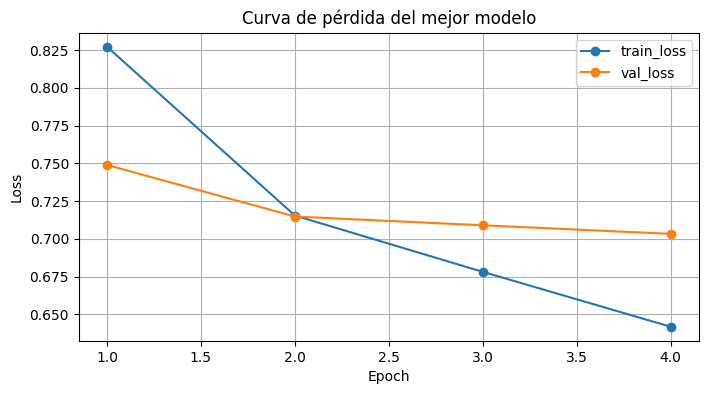

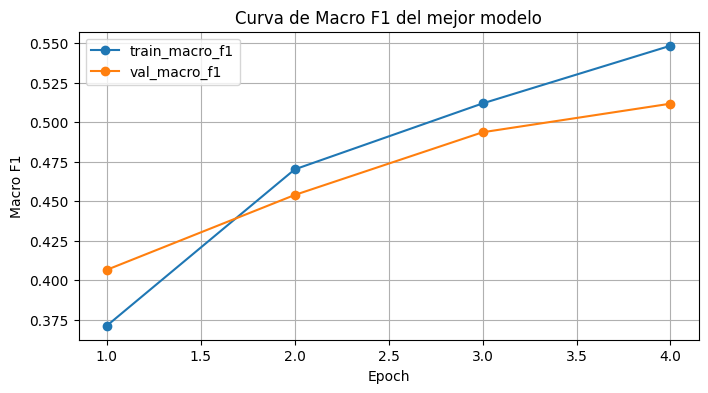

In [36]:
import  matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(best_history_df["epoch"], best_history_df["train_loss"], marker="o", label="train_loss")
plt.plot(best_history_df["epoch"], best_history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de pérdida del mejor modelo")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best_history_df["epoch"], best_history_df["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(best_history_df["epoch"], best_history_df["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Curva de Macro F1 del mejor modelo")
plt.legend()
plt.grid(True)
plt.show()


## 22. Reporte de clasificación del mejor modelo en test


In [37]:
print(best_summary["classification_report"])


              precision    recall  f1-score   support

           0     0.5812    0.5481    0.5642       405
           1     0.4296    0.2459    0.3127       484
           2     0.4913    0.4260    0.4563      1526
           3     0.4976    0.3699    0.4243      4223
           4     0.7893    0.8983    0.8403     10982

    accuracy                         0.7048     17620
   macro avg     0.5578    0.4976    0.5196     17620
weighted avg     0.6789    0.7048    0.6865     17620



## 23. Plantilla de análisis para redactar conclusiones

Esta tabla ayuda a redactar el informe con base en resultados reales.


In [38]:
analysis_template = pd.DataFrame({
    "Pregunta": [
        "¿Qué tokenizador obtuvo mejor validación?",
        "¿Qué positional encoding fue mejor?",
        "¿Embedding pequeño o grande funcionó mejor?",
        "¿Qué valor de beta ayudó más?",
        "¿Hubo sobreajuste visible en las curvas?",
        "¿Cuál configuración se recomienda para el entregable final?"
    ],
    "Respuesta basada en resultados": [""] * 6
})
analysis_template


,Pregunta,Respuesta basada en resultados
0,¿Qué tokenizador obtuvo mejor validación?,
1,¿Qué positional encoding fue mejor?,
2,¿Embedding pequeño o grande funcionó mejor?,
3,¿Qué valor de beta ayudó más?,
4,¿Hubo sobreajuste visible en las curvas?,
5,¿Cuál configuración se recomienda para el entr...,


## 24. Visualización de atención del mejor modelo

Opcional, pero útil para la sustentación.


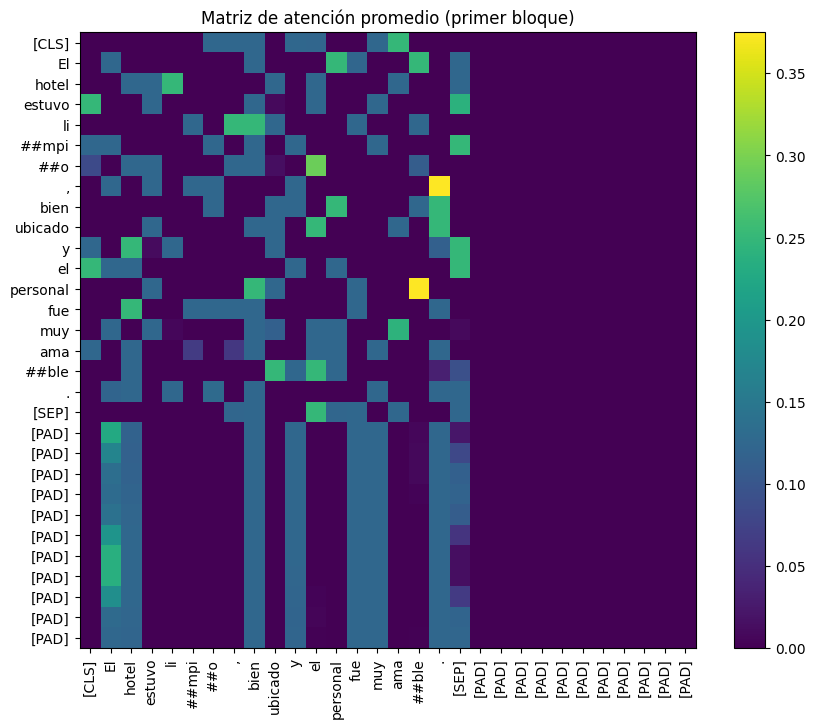

In [49]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def inspect_attention(model: SentimentTransformerClassifier, tokenizer_obj, text: str):
    model.eval()

    encoded = tokenizer_obj(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    emb = model.embedding(input_ids)

    # The TransformerEncoderBlock's attention is accessed via the 'attention' attribute
    # The MultiHeadSelfAttention's forward method takes x and attention_mask
    attn_output, attn_weights = model.encoder.layers[0].attention(emb, attention_mask=attention_mask, return_attention=True)

    tokens = tokenizer_obj.convert_ids_to_tokens(
        input_ids[0].detach().cpu().tolist()
    )

    # attn_weights shape: [batch, num_heads, seq_len, seq_len]
    avg_weights = attn_weights[0].mean(dim=0).detach().cpu().numpy()

    return tokens[:30], avg_weights[:30, :30]


demo_text = "El hotel estuvo limpio, bien ubicado y el personal fue muy amable."
tokens, att_matrix = inspect_attention(best_model, best_tokenizer, demo_text)

plt.figure(figsize=(10, 8))
plt.imshow(att_matrix)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title("Matriz de atención promedio (primer bloque)")
plt.colorbar()
plt.show()

## 25. Predicciones del modelo

En esta sección la inferencia queda conectada directamente al **mejor experimento entrenado**.


In [40]:
def stars_to_sentiment_text(star_value: int) -> str:
    mapping = {
        1: "Muy negativo",
        2: "Negativo",
        3: "Neutral",
        4: "Positivo",
        5: "Muy positivo"
    }
    return mapping.get(int(star_value), f"{star_value} estrellas")

@torch.no_grad()
def predict_text(model, tokenizer_obj, text: str, max_length: Optional[int] = None):
    model.eval()
    max_length = max_length or MAX_LEN

    encoded = tokenizer_obj(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    logits = model(input_ids, attention_mask)
    probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]

    pred_index = int(np.argmax(probs))
    pred_label = pred_index + 1

    return {
        "texto": text,
        "prediccion_label": pred_label,
        "prediccion_sentimiento": stars_to_sentiment_text(pred_label),
        "confianza_prediccion": float(probs[pred_index]),
        "prob_1_estrella": float(probs[0]),
        "prob_2_estrellas": float(probs[1]),
        "prob_3_estrellas": float(probs[2]),
        "prob_4_estrellas": float(probs[3]),
        "prob_5_estrellas": float(probs[4]),
    }

@torch.no_grad()
def predict_dataset_samples(model, tokenizer_obj, dataframe, text_col="text", label_col="label", n=12, seed=42):
    sample_df = dataframe.sample(min(n, len(dataframe)), random_state=seed).copy()
    rows = []

    for _, row in sample_df.iterrows():
        pred = predict_text(model, tokenizer_obj, row[text_col])
        true_label = int(row[label_col])

        rows.append({
            "texto": row[text_col],
            "etiqueta_real": true_label,
            "sentimiento_real": stars_to_sentiment_text(true_label),
            "etiqueta_predicha": pred["prediccion_label"],
            "sentimiento_predicho": pred["prediccion_sentimiento"],
            "confianza": pred["confianza_prediccion"],
            "acerto": int(true_label == pred["prediccion_label"])
        })

    return pd.DataFrame(rows)


### 25.1 Predicciones sobre textos manuales


In [41]:
manual_texts = [
    "El hotel fue excelente, la atención impecable y la vista al mar maravillosa.",
    "La experiencia fue regular, el lugar estaba bien pero el servicio fue lento.",
    "Muy mala experiencia, la habitación estaba sucia y el personal fue grosero.",
    "El destino turístico me encantó, volvería sin dudarlo.",
    "Nada especial, esperaba más por el precio pagado."
]

manual_predictions = pd.DataFrame([
    predict_text(best_model, best_tokenizer, txt) for txt in manual_texts
])

manual_predictions


,texto,prediccion_label,prediccion_sentimiento,confianza_prediccion,prob_1_estrella,prob_2_estrellas,prob_3_estrellas,prob_4_estrellas,prob_5_estrellas
0,"El hotel fue excelente, la atención impecable ...",5,Muy positivo,0.964631,0.000024,0.000024,0.000731,0.034590,0.964631
1,"La experiencia fue regular, el lugar estaba bi...",3,Neutral,0.941179,0.000566,0.014558,0.941179,0.041451,0.002246
2,"Muy mala experiencia, la habitación estaba suc...",1,Muy negativo,0.612674,0.612674,0.358279,0.028451,0.000527,0.000069
3,"El destino turístico me encantó, volvería sin ...",5,Muy positivo,0.793657,0.000680,0.001087,0.016739,0.187837,0.793657
4,"Nada especial, esperaba más por el precio pagado.",3,Neutral,0.727379,0.022454,0.086701,0.727379,0.100965,0.062500


### 25.2 Predicciones sobre ejemplos reales del conjunto de validación


In [42]:
validation_predictions = predict_dataset_samples(
    best_model,
    best_tokenizer,
    val_df_run,
    text_col="text",
    label_col="label",
    n=12,
    seed=7
)
validation_predictions


,texto,etiqueta_real,sentimiento_real,etiqueta_predicha,sentimiento_predicho,confianza,acerto
0,un oasis de tipo. sabíamos que la habana hubie...,4,Positivo,5,Muy positivo,0.517806,0
1,una mirada sobre la ciudad. quien no tiene a l...,4,Positivo,5,Muy positivo,0.839273,0
2,la vieja ciudad amurallada. vale la pena visit...,5,Muy positivo,5,Muy positivo,0.634354,1
3,mal atendido. fui con mi familia y no me gustó...,2,Negativo,3,Neutral,0.672132,0
4,extraño lugar. nos alojamos en mayan palace nu...,3,Neutral,4,Positivo,0.467575,0
5,"total relax. excelente lugar para descansar, l...",5,Muy positivo,5,Muy positivo,0.914366,1
6,robo de dinero. dos veces ya pido para llevar ...,2,Negativo,5,Muy positivo,0.263184,0
7,muy bueno sin embargo hay que mantener mejor e...,4,Positivo,3,Neutral,0.471140,0
8,"¡excelente servicio!. un hotel muy acogedor, e...",5,Muy positivo,5,Muy positivo,0.952076,1
9,una muy mala elección. para tres semanas se ha...,1,Muy negativo,2,Negativo,0.436734,0


### 25.3 Casos correctos y casos con error


In [43]:
correct_cases = validation_predictions[validation_predictions["acerto"] == 1].head(5)
error_cases = validation_predictions[validation_predictions["acerto"] == 0].head(5)

print("Casos correctos:")
display(correct_cases)

print("Casos con error:")
display(error_cases)


Casos correctos:


,texto,etiqueta_real,sentimiento_real,etiqueta_predicha,sentimiento_predicho,confianza,acerto
2,la vieja ciudad amurallada. vale la pena visit...,5,Muy positivo,5,Muy positivo,0.634354,1
5,"total relax. excelente lugar para descansar, l...",5,Muy positivo,5,Muy positivo,0.914366,1
8,"¡excelente servicio!. un hotel muy acogedor, e...",5,Muy positivo,5,Muy positivo,0.952076,1
10,muy interesante. museo muy interesante con num...,5,Muy positivo,5,Muy positivo,0.717781,1
11,una experiencia increíble con la naturaleza y ...,5,Muy positivo,5,Muy positivo,0.953064,1


Casos con error:


,texto,etiqueta_real,sentimiento_real,etiqueta_predicha,sentimiento_predicho,confianza,acerto
0,un oasis de tipo. sabíamos que la habana hubie...,4,Positivo,5,Muy positivo,0.517806,0
1,una mirada sobre la ciudad. quien no tiene a l...,4,Positivo,5,Muy positivo,0.839273,0
3,mal atendido. fui con mi familia y no me gustó...,2,Negativo,3,Neutral,0.672132,0
4,extraño lugar. nos alojamos en mayan palace nu...,3,Neutral,4,Positivo,0.467575,0
6,robo de dinero. dos veces ya pido para llevar ...,2,Negativo,5,Muy positivo,0.263184,0


### 25.4 Predicción de un texto nuevo

Durante la sustentación puedes cambiar el contenido de `texto_nuevo` y volver a ejecutar la celda.


In [44]:
texto_nuevo = "La comida fue deliciosa, el sitio muy limpio y la atención excelente."
pred_nuevo = predict_text(best_model, best_tokenizer, texto_nuevo)
pd.DataFrame([pred_nuevo])


,texto,prediccion_label,prediccion_sentimiento,confianza_prediccion,prob_1_estrella,prob_2_estrellas,prob_3_estrellas,prob_4_estrellas,prob_5_estrellas
0,"La comida fue deliciosa, el sitio muy limpio y...",5,Muy positivo,0.992418,0.00001,0.000005,0.000079,0.007488,0.992418


## 26. Conclusiones esperadas para el informe

1. La comparación entre tokenizadores permite justificar con evidencia cuál fragmenta mejor el español del dataset.
2. La comparación entre **sinusoidal** y **learnable** permite responder exactamente el requerimiento del profesor.
3. La exploración con `beta` y con embedding grande muestra ajuste de hiperparámetros sin modificar el corazón del Transformer.
4. La mejor configuración queda identificada automáticamente y luego se usa en inferencia.
5. El notebook ya no se limita a entrenar: ahora también **evalúa, compara y predice**.


## 27. Qué mejoró frente a la versión anterior

- ya no hay celdas críticas comentadas,
- los experimentos obligatorios corren automáticamente,
- el mejor modelo se selecciona solo,
- las predicciones usan explícitamente ese mejor modelo,
- se guarda checkpoint,
- se generan curvas de entrenamiento,
- queda listo para mostrar resultados en la entrega.
